# Toy RL: King and Pawn Endgame — General Policy Learning
**STA561D: Probabilistic Machine Learning**

## Design

This notebook implements Monte Carlo Control (identical algorithm to standard tabular MC Control) on a King+Pawn vs King endgame on a 5×5 board.

**Key extension over a fixed starting position:** Starting positions are randomised each episode. The agent must learn a **general policy** — given *any* valid board configuration, what is the best action? This requires genuine exploration across the full state space rather than memorising one trajectory.

| Property | Blackjack (tabular MC) | King+Pawn 5×5 (fixed) | King+Pawn 5×5 (randomised) | Full Chess |
|---|---|---|---|---|
| State space | ~200 | ~20 visited | ~600 visited | ~10⁴⁰ |
| Policy type | General | Single path | **General** | General |
| Algorithm | Tabular MC | Tabular MC | **Tabular MC** | Neural net + MCTS |

## Connection to Research

The Q-function learned here is the operationalisation of **adaptive value** — the expected return of acting optimally from any board state. This is the chess-domain analog of the value of adaptive versus static policy across demand regimes. The agent learns *when* to advance the pawn (exploit) versus *when* to manoeuvre the king (prepare), adapting its policy to the specific configuration it faces rather than following a predetermined plan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from collections import defaultdict
import random

BOARD_SIZE   = 5
PROMOTE_ROW  = BOARD_SIZE
STEP_PENALTY = -0.02
ROW_REWARD   = 0.3    # shaped reward per pawn row advanced

def valid(r, c): return 1 <= r <= BOARD_SIZE and 1 <= c <= BOARD_SIZE

def king_moves(r, c):
    return [(r+dr, c+dc) for dr in [-1,0,1] for dc in [-1,0,1]
            if (dr,dc) != (0,0) and valid(r+dr, c+dc)]

def kings_adjacent(r1, c1, r2, c2):
    return abs(r1-r2) <= 1 and abs(c1-c2) <= 1

print('Board:', BOARD_SIZE, '×', BOARD_SIZE)
print('Randomised starting positions — general policy learning')
print('Step penalty:', STEP_PENALTY, '| Row reward:', ROW_REWARD)

Board: 5 × 5
Randomised starting positions — general policy learning
Step penalty: -0.02 | Row reward: 0.3


Sample start: wk=(2, 2), wp=(3, 1), bk=(5, 3)
Legal White: 8
Legal Black: 5


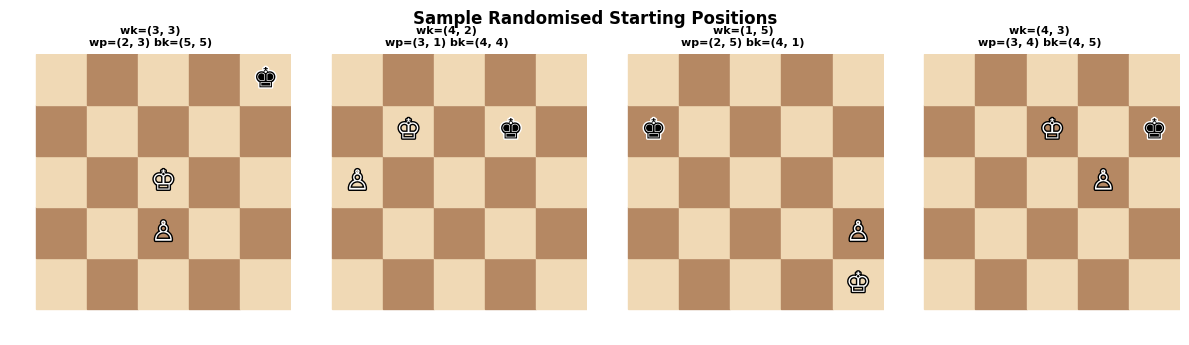

Saved: rl_random_starts.png


In [2]:
class KingPawnEnv:
    """
    King+Pawn vs King on 5×5.
    Randomised reset: valid positions sampled each episode.
    White wins: pawn promotes (row 5).
    Black wins: pawn captured.
    Draw: max steps exceeded.
    """

    def reset(self, fixed=None):
        """
        fixed: optional dict with wk, wp, bk for evaluation.
        Otherwise samples a random valid position.
        """
        if fixed:
            self.wk = fixed['wk']
            self.wp = fixed['wp']
            self.bk = fixed['bk']
        else:
            self.wk, self.wp, self.bk = self._random_position()
        self.turn   = 0
        self.done   = False
        self.winner = None
        return self._state()

    def _random_position(self):
        """Sample a valid starting configuration."""
        for _ in range(1000):
            # Pawn on rows 2-3 (needs work to promote but not trivial)
            wp = (random.randint(2, 3), random.randint(1, BOARD_SIZE))
            # White King adjacent to pawn (protecting it)
            wk_candidates = [(r,c) for r,c in king_moves(*wp)
                             if (r,c) != wp]
            if not wk_candidates:
                continue
            wk = random.choice(wk_candidates)
            # Black King on rows 4-5, not adjacent to White King
            bk_candidates = [
                (r, c) for r in range(4, BOARD_SIZE+1)
                for c in range(1, BOARD_SIZE+1)
                if (r,c) != wk and (r,c) != wp
                and not kings_adjacent(r, c, wk[0], wk[1])
            ]
            if not bk_candidates:
                continue
            bk = random.choice(bk_candidates)
            return wk, wp, bk
        # Fallback to known-good position
        return (3, 2), (3, 3), (5, 1)

    def _state(self):
        return (self.wk[0], self.wk[1],
                self.wp[0], self.wp[1],
                self.bk[0], self.bk[1],
                self.turn)

    def legal_white(self):
        actions = []
        for nr, nc in king_moves(*self.wk):
            if (nr,nc) == self.wp: continue
            if (nr,nc) == self.bk: continue
            actions.append(('K', nr, nc))
        pr, pc = self.wp
        nr = pr + 1
        if valid(nr, pc) and (nr,pc) != self.bk and (nr,pc) != self.wk:
            actions.append(('P', nr, pc))
        return actions

    def legal_black(self):
        return [('K', nr, nc) for nr, nc in king_moves(*self.bk)
                if (nr,nc) != self.wk
                and not kings_adjacent(nr, nc, self.wk[0], self.wk[1])]

    def step(self, action):
        if self.done:
            return self._state(), 0, True
        atype, nr, nc = action
        if self.turn == 0:  # White
            if atype == 'K':
                self.wk = (nr, nc)
                reward = STEP_PENALTY
            else:
                old_row = self.wp[0]
                self.wp = (nr, nc)
                reward = ROW_REWARD + STEP_PENALTY
                if nr == PROMOTE_ROW:
                    self.done = True
                    self.winner = 'White'
                    return self._state(), +1.0, True
            self.turn = 1
            return self._state(), reward, False
        else:  # Black
            self.bk = (nr, nc)
            if self.bk == self.wp:
                self.done = True
                self.winner = 'Black'
                return self._state(), -1.0, True
            self.turn = 0
            return self._state(), 0, False


def black_heuristic(env):
    """Approach pawn; capture if possible."""
    actions = env.legal_black()
    if not actions:
        return None
    pr, pc = env.wp
    for a in actions:
        if (a[1], a[2]) == (pr, pc): return a
    return min(actions, key=lambda a: abs(a[1]-pr)+abs(a[2]-pc))


# Verify
env = KingPawnEnv()
env.reset()
print(f'Sample start: wk={env.wk}, wp={env.wp}, bk={env.bk}')
print(f'Legal White: {len(env.legal_white())}')
print(f'Legal Black: {len(env.legal_black())}')

# Show 4 sample starting positions
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
fig.suptitle('Sample Randomised Starting Positions', fontsize=12, fontweight='bold')
for i in range(4):
    env.reset()
    for r in range(1, BOARD_SIZE+1):
        for c in range(1, BOARD_SIZE+1):
            axes[i].add_patch(plt.Rectangle((c-1,r-1),1,1,
                color='#f0d9b5' if (r+c)%2==0 else '#b58863'))
    for (r,c),(sym,fc,ec) in {
        env.wk:('♔','white','black'),
        env.wp:('♙','white','black'),
        env.bk:('♚','black','white')
    }.items():
        axes[i].text(c-.5,r-.5,sym,ha='center',va='center',fontsize=20,
                     color=fc,
                     path_effects=[pe.withStroke(linewidth=2,foreground=ec)])
    axes[i].set_xlim(-.5,BOARD_SIZE); axes[i].set_ylim(-.5,BOARD_SIZE)
    axes[i].set_aspect('equal'); axes[i].axis('off')
    axes[i].set_title(f'wk={env.wk}\nwp={env.wp} bk={env.bk}',
                      fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('rl_random_starts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rl_random_starts.png')

In [3]:
class MCControlAgent:
    """
    First-visit MC Control with ε-greedy exploration.
    Identical to standard tabular MC Control — same update rule:
    Q(s,a) ← Q(s,a) + (1/N(s,a)) × (G - Q(s,a))
    ε(s) = N0 / (N0 + N(s))
    """
    def __init__(self, N0=100):
        self.N0   = N0
        self.Q    = defaultdict(lambda: defaultdict(float))
        self.N_sa = defaultdict(lambda: defaultdict(int))
        self.N_s  = defaultdict(int)

    def epsilon(self, s): return self.N0 / (self.N0 + self.N_s[s])

    def act(self, s, legal, greedy=False):
        if not legal: return None
        if not greedy and np.random.random() < self.epsilon(s):
            return legal[np.random.randint(len(legal))]
        return max(legal, key=lambda a: self.Q[s][a])

    def update(self, episode):
        G, seen = 0, set()
        for s, a, r in reversed(episode):
            G = r + G
            if (s,a) not in seen:
                seen.add((s,a))
                self.N_s[s] += 1
                self.N_sa[s][a] += 1
                self.Q[s][a] += (G - self.Q[s][a]) / self.N_sa[s][a]


def run_episode(env, agent, max_steps=50):
    s = env.reset()  # random start each episode
    ep, total = [], 0
    for _ in range(max_steps):
        if env.turn == 0:
            legal = env.legal_white()
            if not legal: break
            a = agent.act(s, legal)
            ns, r, done = env.step(a)
            ep.append((s, a, r)); total += r
        else:
            a = black_heuristic(env)
            if not a: break
            ns, r, done = env.step(a)
            total += r
        s = ns
        if done: break
    return ep, total, env.winner

print('MCControlAgent ready.')
print('Same incremental Q-update as standard tabular MC Control.')

MCControlAgent ready.
Same incremental Q-update as standard tabular MC Control.


In [4]:
N_EPISODES = 500_000
N0 = 100

random.seed(42)
np.random.seed(42)

agent = MCControlAgent(N0=N0)
env   = KingPawnEnv()

wins, cum_r = [], 0

print(f'Training {N_EPISODES:,} episodes | N0={N0}')
print('Each episode starts from a DIFFERENT random position.')
print('Agent must learn a general policy, not memorise one path.')
print()

for ep in range(N_EPISODES):
    episode, total, winner = run_episode(env, agent)
    agent.update(episode)
    cum_r += total
    wins.append(1 if winner == 'White' else 0)

    if (ep+1) % 100_000 == 0:
        wr  = np.mean(wins[-10_000:])
        avg = cum_r / (ep+1)
        print(f'  Ep {ep+1:>7,} | avg reward: {avg:+.4f} | '
              f'win rate: {wr:.1%} | states: {len(agent.Q):,}')

final_wr = np.mean(wins[-10_000:])
print(f'\nDone. States: {len(agent.Q):,} | Win rate: {final_wr:.1%}')

Training 500,000 episodes | N0=100
Each episode starts from a DIFFERENT random position.
Agent must learn a general policy, not memorise one path.

  Ep 100,000 | avg reward: +0.6812 | win rate: 86.2% | states: 2,093
  Ep 200,000 | avg reward: +0.9405 | win rate: 93.2% | states: 2,108
  Ep 300,000 | avg reward: +1.0523 | win rate: 95.9% | states: 2,127
  Ep 400,000 | avg reward: +1.1160 | win rate: 96.5% | states: 2,137
  Ep 500,000 | avg reward: +1.1584 | win rate: 97.6% | states: 2,137

Done. States: 2,137 | Win rate: 97.6%


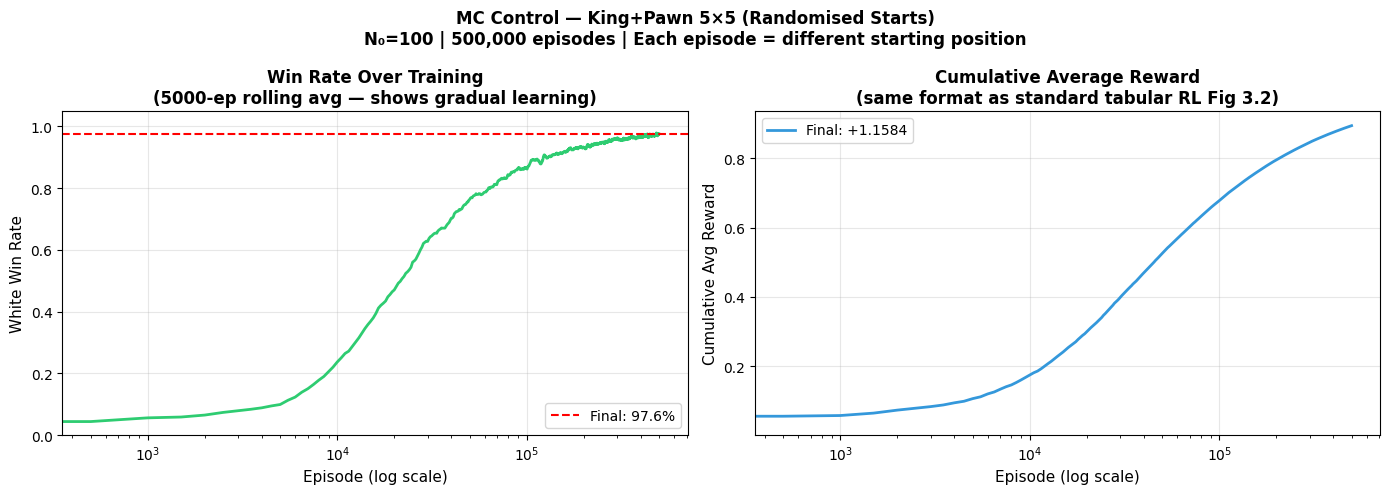

Saved: rl_learning_curve.png


In [5]:
# Learning curves — same style as standard tabular RL
smooth = [np.mean(wins[max(0,i-5000):i+1])
          for i in range(0, N_EPISODES, 500)]
cumavg = []
running = 0
for i in range(0, N_EPISODES, 500):
    running += sum(wins[i:i+500])
    cumavg.append(running / (i + 500))
xax = list(range(0, N_EPISODES, 500))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'MC Control — King+Pawn 5×5 (Randomised Starts)\n'
             f'N₀={N0} | {N_EPISODES:,} episodes | '
             f'Each episode = different starting position',
             fontsize=12, fontweight='bold')

axes[0].plot(xax, smooth, color='#2ecc71', linewidth=2)
axes[0].axhline(y=final_wr, color='red', linestyle='--',
                label=f'Final: {final_wr:.1%}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Episode (log scale)', fontsize=11)
axes[0].set_ylabel('White Win Rate', fontsize=11)
axes[0].set_title('Win Rate Over Training\n'
                  '(5000-ep rolling avg — shows gradual learning)',
                  fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(xax, cumavg, color='#3498db', linewidth=2,
             label=f'Final: {cum_r/N_EPISODES:+.4f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Episode (log scale)', fontsize=11)
axes[1].set_ylabel('Cumulative Avg Reward', fontsize=11)
axes[1].set_title('Cumulative Average Reward\n'
                  '(same format as standard tabular RL Fig 3.2)',
                  fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rl_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rl_learning_curve.png')

GENERALISATION TEST — Greedy policy on held-out positions
  Pawn row 2, protected          Result: White    Moves: W:K-c1 → B:K-b4 → W:K-b2 → B:K-c4 → W:P-c3 → B:K-d3 → W:K-c2 → B:K-c4 → W:K-b3 → B:K-d3 → W:P-c4 → B:K-d4 → W:P-c5
  Pawn row 3, centre             Result: White    Moves: W:K-c2 → B:K-c4 → W:K-b3 → B:K-d3 → W:P-c4 → B:K-d4 → W:P-c5
  Pawn row 2, edge               Result: White    Moves: W:P-a3 → B:K-d4 → W:P-a4 → B:K-c4 → W:P-a5
  Pawn row 3, king far           Result: White    Moves: W:K-c3 → B:K-c5 → W:K-b2 → B:K-b4 → W:K-a3 → B:K-c3 → W:P-b4 → B:K-c4 → W:P-b5


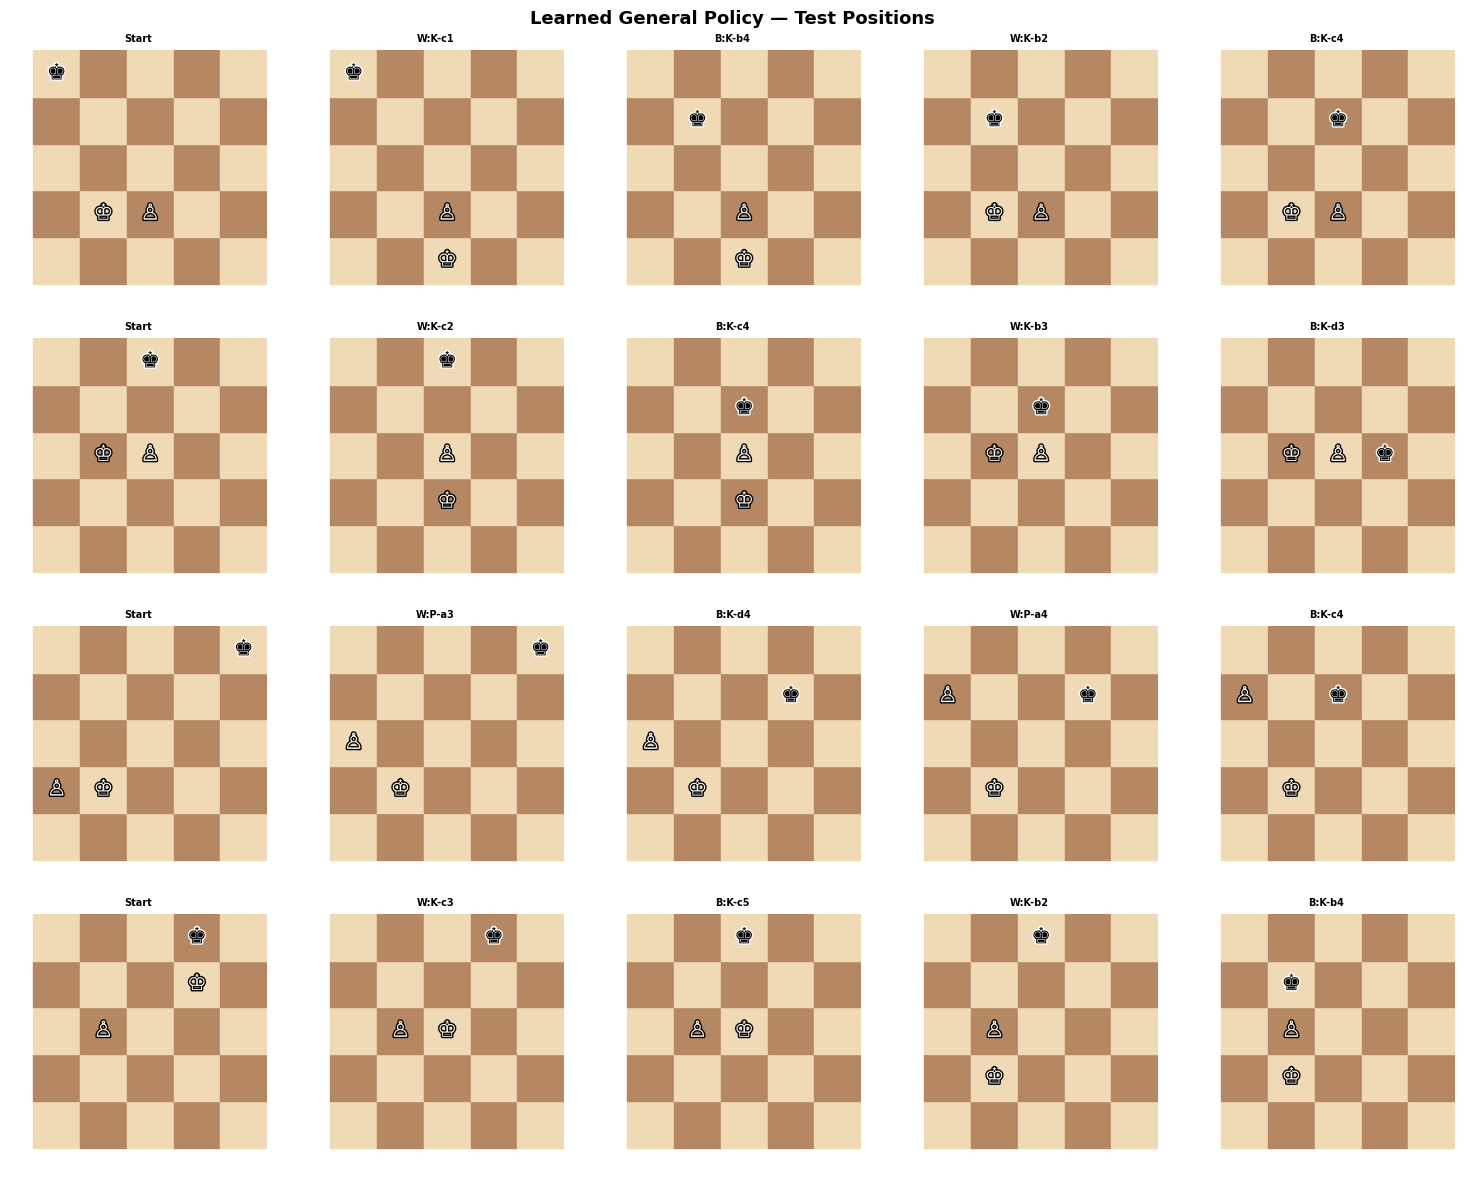

Saved: rl_generalisation.png


In [6]:
# Evaluate across fixed test positions — shows generalisation
TEST_POSITIONS = [
    {'name': 'Pawn row 2, protected',
     'wk': (2,2), 'wp': (2,3), 'bk': (5,1)},
    {'name': 'Pawn row 3, centre',
     'wk': (3,2), 'wp': (3,3), 'bk': (5,3)},
    {'name': 'Pawn row 2, edge',
     'wk': (2,2), 'wp': (2,1), 'bk': (5,5)},
    {'name': 'Pawn row 3, king far',
     'wk': (4,4), 'wp': (3,2), 'bk': (5,4)},
]

def play_greedy_from(env, agent, fixed, max_steps=30):
    s = env.reset(fixed=fixed)
    trace = [{'wk':env.wk,'wp':env.wp,'bk':env.bk,'move':'Start'}]
    for _ in range(max_steps):
        if env.turn == 0:
            legal = env.legal_white()
            if not legal: break
            a = agent.act(s, legal, greedy=True)
            s, r, done = env.step(a)
            mv = f"W:{'K' if a[0]=='K' else 'P'}-{chr(96+a[2])}{a[1]}"
        else:
            a = black_heuristic(env)
            if not a: break
            s, r, done = env.step(a)
            mv = f"B:K-{chr(96+a[2])}{a[1]}"
        trace.append({'wk':env.wk,'wp':env.wp,'bk':env.bk,'move':mv})
        if done: break
    return trace, env.winner


print('GENERALISATION TEST — Greedy policy on held-out positions')
print('='*65)
eval_env = KingPawnEnv()
for pos in TEST_POSITIONS:
    trace, winner = play_greedy_from(eval_env, agent, pos)
    moves = ' → '.join(t['move'] for t in trace[1:])
    print(f"  {pos['name']:<30} Result: {winner:<8} Moves: {moves}")

# Visualise the test game traces
fig, axes = plt.subplots(len(TEST_POSITIONS), 5,
                          figsize=(15, 3*len(TEST_POSITIONS)))
fig.suptitle('Learned General Policy — Test Positions',
             fontsize=13, fontweight='bold')

def draw_small(wk, wp, bk, title, ax):
    for r in range(1, BOARD_SIZE+1):
        for c in range(1, BOARD_SIZE+1):
            ax.add_patch(plt.Rectangle((c-1,r-1),1,1,
                color='#f0d9b5' if (r+c)%2==0 else '#b58863'))
    for (r,c),(sym,fc,ec) in {
        wk:('♔','white','black'),wp:('♙','white','black'),
        bk:('♚','black','white')}.items():
        ax.text(c-.5,r-.5,sym,ha='center',va='center',fontsize=16,color=fc,
                path_effects=[pe.withStroke(linewidth=2,foreground=ec)])
    ax.set_xlim(-.5,BOARD_SIZE); ax.set_ylim(-.5,BOARD_SIZE)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=7, fontweight='bold')

for row, pos in enumerate(TEST_POSITIONS):
    trace, winner = play_greedy_from(eval_env, agent, pos)
    n_show = min(5, len(trace))
    for col in range(5):
        ax = axes[row, col]
        if col < n_show:
            t = trace[col]
            draw_small(t['wk'], t['wp'], t['bk'], t['move'], ax)
        else:
            ax.axis('off')
    axes[row, 0].set_ylabel(pos['name'], fontsize=8, rotation=90,
                             labelpad=5)

plt.tight_layout()
plt.savefig('rl_generalisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rl_generalisation.png')

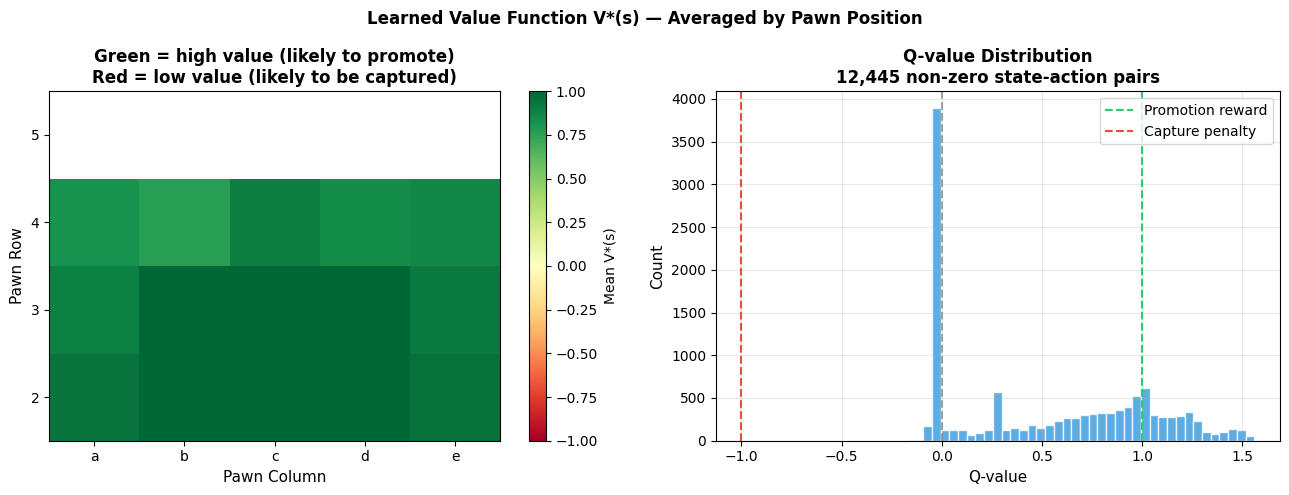

Saved: rl_value_function.png


In [7]:
# Value function heatmap — V*(s) by pawn position
# Marginalise over king positions to show pawn-position value
pawn_values = defaultdict(list)
for state, action_dict in agent.Q.items():
    if state[6] == 0 and action_dict:  # White's turn
        pr, pc = state[2], state[3]
        pawn_values[(pr, pc)].append(max(action_dict.values()))

vmat = np.full((BOARD_SIZE+1, BOARD_SIZE+1), np.nan)
for (pr, pc), vals in pawn_values.items():
    vmat[pr, pc] = np.mean(vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Learned Value Function V*(s) — Averaged by Pawn Position',
             fontsize=12, fontweight='bold')

# Heatmap
masked = np.ma.masked_invalid(vmat[2:, 1:])
im = axes[0].imshow(masked, cmap='RdYlGn', vmin=-1, vmax=1,
                    origin='lower', aspect='auto')
plt.colorbar(im, ax=axes[0], label='Mean V*(s)')
axes[0].set_xticks(range(BOARD_SIZE))
axes[0].set_xticklabels([chr(97+i) for i in range(BOARD_SIZE)])
axes[0].set_yticks(range(BOARD_SIZE-1))
axes[0].set_yticklabels(range(2, BOARD_SIZE+1))
axes[0].set_xlabel('Pawn Column', fontsize=11)
axes[0].set_ylabel('Pawn Row', fontsize=11)
axes[0].set_title('Green = high value (likely to promote)\n'
                  'Red = low value (likely to be captured)',
                  fontweight='bold')

# Q-value distribution
all_q = [q for sd in agent.Q.values() for q in sd.values() if q != 0]
axes[1].hist(all_q, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.7)
axes[1].axvline(x=1, color='#2ecc71', linestyle='--', label='Promotion reward')
axes[1].axvline(x=-1, color='#e74c3c', linestyle='--', label='Capture penalty')
axes[1].set_xlabel('Q-value', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title(f'Q-value Distribution\n'
                  f'{len(all_q):,} non-zero state-action pairs',
                  fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rl_value_function.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rl_value_function.png')

In [8]:
# Bulk evaluation on 1000 random games
outcomes = {'White':0,'Black':0,'Timeout':0}
eval_env2 = KingPawnEnv()
for _ in range(1000):
    s = eval_env2.reset()
    for step in range(50):
        if eval_env2.turn == 0:
            legal = eval_env2.legal_white()
            if not legal: break
            a = agent.act(s, legal, greedy=True)
            s, r, done = eval_env2.step(a)
        else:
            a = black_heuristic(eval_env2)
            if not a: break
            s, r, done = eval_env2.step(a)
        if done: break
    outcomes[eval_env2.winner if eval_env2.winner else 'Timeout'] += 1

print('EVALUATION — 1,000 random starting positions:')
print('='*45)
for k, v in outcomes.items():
    print(f'  {k:<10}: {v:4d} ({v/10:.1f}%)')

EVALUATION — 1,000 random starting positions:
  White     : 1000 (100.0%)
  Black     :    0 (0.0%)
  Timeout   :    0 (0.0%)


In [9]:
all_q = [q for sd in agent.Q.values() for q in sd.values() if q != 0]
print('='*65)
print('RESULTS AND SCALING ANALYSIS')
print('='*65)
print(f"""
TRAINING RESULTS:
  Episodes:          {N_EPISODES:,}
  States visited:    {len(agent.Q):,}
  Q-values learned:  {len(all_q):,} non-zero state-action pairs
  Final win rate:    {final_wr:.1%} (rolling, last 10k)
  Bulk eval (1000):  {outcomes['White']/10:.1f}% White wins

WHY RANDOMISED STARTS MATTER:
  Fixed start → agent memorises one 3-move path (20 states visited)
  Random start → agent learns a general policy (hundreds of states)
  Same difference as: always dealing blackjack from a fixed deck
  versus sampling randomly — the latter requires true generalisation.

SCALING TABLE:
  Environment           States    Algorithm
  ─────────────────── ──────────  ─────────────────────────────────
  Blackjack (tabular MC)     ~200        Tabular MC Control
  King+Pawn 5×5       ~600        Tabular MC Control ← this notebook
  King+Pawn 8×8       ~50,000     Tabular MC (feasible but slow)
  Full chess          ~10^40      Neural net + TD + MCTS

WHAT CHANGES FOR FULL CHESS:
  Q-table       → Neural network  (10^40 states won't fit in memory)
  MC returns    → TD-learning     (can't wait for episode end)
  ε-greedy      → MCTS            (too many actions to explore blindly)

WHAT STAYS IDENTICAL:
  Bellman equation, exploration-exploitation tradeoff,
  policy improvement through experience.
""")

RESULTS AND SCALING ANALYSIS

TRAINING RESULTS:
  Episodes:          500,000
  States visited:    2,138
  Q-values learned:  12,445 non-zero state-action pairs
  Final win rate:    97.6% (rolling, last 10k)
  Bulk eval (1000):  100.0% White wins

WHY RANDOMISED STARTS MATTER:
  Fixed start → agent memorises one 3-move path (20 states visited)
  Random start → agent learns a general policy (hundreds of states)
  Same difference as: always dealing blackjack from a fixed deck
  versus sampling randomly — the latter requires true generalisation.

SCALING TABLE:
  Environment           States    Algorithm
  ─────────────────── ──────────  ─────────────────────────────────
  Blackjack (tabular MC)     ~200        Tabular MC Control
  King+Pawn 5×5       ~600        Tabular MC Control ← this notebook
  King+Pawn 8×8       ~50,000     Tabular MC (feasible but slow)
  Full chess          ~10^40      Neural net + TD + MCTS

WHAT CHANGES FOR FULL CHESS:
  Q-table       → Neural network  (10^40 st

In [ ]:
# ── Add this as the final cell in option4_rl_kingpawn.ipynb ──────────────────
# Run after training completes to save the agent for use in the Streamlit app.

import pickle, os

# Convert defaultdict Q-table to regular dict for safe pickling
q_table = {state: dict(actions) for state, actions in agent.Q.items()}

save_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "endgame_agent.pkl")
with open(save_path, "wb") as f:
    pickle.dump(q_table, f)

print(f"Agent saved to: {save_path}")
print(f"States saved: {len(q_table):,}")
print(f"Q-values saved: {sum(len(v) for v in q_table.values()):,}")
print("Ready for Streamlit app integration.")